<b><font size="6"> Cars 4 You: Predicting Car Values with ML </font></b><br><br>

`Group 40`

Ana Macedo (20250405)<br>
Catarina Mendinhas (20250422)<br>
Lourenço Silva (20250453)<br>
Maria Fonseca (20250380)<br>

### <font color= '#BFD72F'>**Methodology** </font><a class="anchor" id='top'></a>

- [1. Abstract](#1)
- [2. Import Libraries](#2)
- [3. Metadata](#3)
- [4. Import Datasets](#4)
- [5. Feature Selection](#5)
    - [5.1 Filter Methods](#5_1)
        - [5.1.1 Removing Constant Features](#5_1_1)
        - [5.1.2 Correlation between features - Redundant Features](#5_1_2)
        - [5.1.3 Correlation with the target - Relevant Features](#5_1_3)
            - [5.1.3.1 Spearman Correlation](#5_1_3_1)
    - [5.2 Wrapped Methods](#5_2)
        - [5.2.1 RFE](#5_2_1)
    - [5.3 Embedded Methods](#5_3)
        - [5.3.1 Lasso](#5_3_1)
    - [5.4 Comparison between Models](#5_4)
- [6 Save the Data](#6)
- [7 End of The Notebook](#7)


<a class="anchor" id="1">

# **1. Abstract**

[Back to TOP](#TOP)
</a>

This project aims to develop a predictive model capable of estimating car prices based on their characteristics, using the Cars 4 You dataset. The goal is to support the company’s evaluation process by introducing an automated solution that accelerates car assessments and improves overall efficiency.

The current phase of the project focuses on feature selection, aiming to identify the most relevant features for predicting car prices. Different techniques were applied to evaluate the importance and contribution of each feature, reduce redundancy, and minimize noise in the data and improve signal.

In this notebook, many of the sections include helper functions created to streamline the implementation of feature selection techniques. These functions make it easier to apply the same process consistently across the training, test, and validation datasets.

<a class="anchor" id="2">

# **2. Import Libraries**

[Back to TOP](#TOP)
</a>

The following libraries will help us develop the analyses and model for this project. Pandas and Numpy, provide the efficient tools for data manipulation, cleaning and numerical computations. Matplotlib and Seaborn are used to create clear and informative visualizations. Scikit-learn offers a range of Machine Learning tools for model training, spliting the data and evaluate model performance. Finally, os, math and ceil are imported to support file management and mathematical operations.

In [ ]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from math import ceil
import math


#filter methods
from sklearn.feature_selection import VarianceThreshold
from scipy.stats import spearmanr
# spearman 
from sklearn.feature_selection import SelectKBest, f_regression

# mutual information
from sklearn.feature_selection import mutual_info_classif

#wrapper methods
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.feature_selection import RFE


# embedded methods
from sklearn.linear_model import Lasso

# Load Created Functions
from visualizations import *
from data_preprocessing import *

# Set random seed for reproducibility
np.random.seed(40111) 


<a class="anchor" id="3">

# **3. Create Meta Data**

[Back to TOP](#TOP)
</a>

Understanding the features helps interpret the data correctly and supports subsequent analysis and modeling steps. This section provides a brief description of each feature in the dataset, explaining its meaning and type.

**carID:** An atribute that contains an identifier for each car.

**Brand:** The cars main brand (e.g., Ford, Toyota).

**model:** The car model.

**year:** The year of registration of the car.

**price:** The car's price when purchased by Cars 4 You (in £).

**transmission:** The car's type of transmission.

**mileage:** The total reported distance travelled by the car (in miles).

**fuelType:** Type of Fuel used by car (Diesel, Petrol, Hybrid, Electric).

**tax:** The amount of road tax (in £) that, in 2020, was applicable to the car in question.

**mpg:** Average Miles per Gallon.

**engineSize:** Size of Engine in liters (Cubic Decimeters).

**paintQuality%** The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation). 

**previousOwner:** Number of previous registered owners of the vehicle.

**hasDamage:** Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not.



<a class="anchor" id="4">

# **4. Import Dataset**

[Back to TOP](#TOP)
</a>

In this section, we load the preprocessed datasets that were previously saved after the data preprocessing steps. These datasets are ready for feature selection and further analysis.

In [2]:
# Define relative path to the preprocessed data folder (outside "notebooks/")
data_path = "../data_preprocessed/"

# Load preprocessed datasets
X_train = pd.read_csv(f"{data_path}X_train_preprocessed.csv", index_col=0)
X_val   = pd.read_csv(f"{data_path}X_val_preprocessed.csv", index_col=0)
test    = pd.read_csv(f"{data_path}test_preprocessed.csv", index_col=0)

y_train = pd.read_csv(f"{data_path}y_train.csv", index_col=0).squeeze()  # convert DataFrame → Series
y_val   = pd.read_csv(f"{data_path}y_val.csv", index_col=0).squeeze()

In [3]:
X_train.shape

(60778, 237)

<a class="anchor" id="5">

# **5. Feature Selection**

[Back to TOP](#TOP)
</a>

The feature selection pipeline we will implement has the following structure: First of all, we will remove the features gotten from the mechanic's evaluation. Then, we use filter methods to reduce noise by removing constant and redundant variables. After that, we used Spearman and ANOVA to see which features were most correlated with the target. Then we considered using RFE to further reduce dimensionality, but we found that it had a very high computational cost and opted to use the Elastic Net model instead.

Finally, we compared the Spearman, ANOVA and Elastic Net methods to make a final decision. We defined thresholds for each step so that we can change them and see if the model's performance improves.

<a class="anchor" id="5_1">

## **5.1 Remove Features that don't make sense**

[Back to TOP](#TOP)
</a>

Before anything else, we will drop the features related to the mechanic's evaluation: hasDamage and paintQuality%. This decision came from our EDA where we concluded that this information comes from the mechanic's evaluation and this ML project is replace this part of the process and thus function without this information.

In [4]:
X_train.shape

(60778, 237)

In [5]:
X_train = X_train.drop(['paintQuality%', 'hasDamage'], axis=1, errors='ignore')
X_val = X_val.drop(['paintQuality%', 'hasDamage'], axis=1, errors='ignore')

In [6]:
X_train.shape

(60778, 236)

<a class="anchor" id="5_1">

## **5.1 Filter Methods**

[Back to TOP](#TOP)
</a>

Filter methods are ideal for an initial screening of high-dimensional datasets due to their simplicity, even though they are considered less effective than model-based methods.
In this section, we will explore three filter-based techniques to select the features.

<a class="anchor" id="5_1_1">

### **5.1.1 Removing Constant Features**

[Back to TOP](#TOP)
</a>

This method identifies features that have low or zero variance, which are unlikely to contribute meaningful information to the model, and thus can help to reduce noise and improve efficiency.

In [ ]:
def apply_variance_filter(X_train, X_val, X_test, threshold=0.0):
    """ Removes constant or low-variance numerical features based on training data only."""

    # Select numerical columns
    num_cols = X_train.select_dtypes(include='number').columns

    # Fit selector on training data
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(X_train[num_cols])

    # Get kept feature names
    kept_features = num_cols[selector.get_support()]
    removed_features = [c for c in num_cols if c not in kept_features]

    # Keep same columns in all datasets
    cols_to_keep = kept_features.tolist() + X_train.select_dtypes(exclude='number').columns.tolist()
    X_train_f = X_train[cols_to_keep]
    X_val_f   = X_val[cols_to_keep]
    X_test_f  = X_test[cols_to_keep]

    # Display summary
    print(f"Variance threshold = {threshold}")
    print(f"Removed {len(removed_features)} feature(s): {removed_features}" if removed_features else "No features removed.")
    
    return X_train_f, X_val_f, X_test_f


After defining the function, we will analyze the results across different threshold values to decide on the appropriate cutoff and determine which features should be removed.

In [8]:
# Test a few thresholds to see which removes uninformative features
for thr in [0.0, 0.001, 0.01]:
    print(f"\n--- Threshold = {thr} ---")
    X_train_fs, X_val_fs, test_fs = apply_variance_filter(X_train, X_val, test, threshold=thr)


--- Threshold = 0.0 ---
Variance threshold = 0.0
No features removed.

--- Threshold = 0.001 ---
Variance threshold = 0.001
Removed 102 feature(s): ['model_ 3 Serie', 'model_ 6 Series', 'model_ 7 Series', 'model_ 8 Series', 'model_ A2', 'model_ Accent', 'model_ Agila', 'model_ Ampera', 'model_ Antara', 'model_ Beetle', 'model_ CC', 'model_ CL Clas', 'model_ Caddy', 'model_ Caddy Life', 'model_ Caddy Maxi', 'model_ Caddy Maxi Life', 'model_ California', 'model_ Camry', 'model_ Caravelle', 'model_ Cascada', 'model_ Eos', 'model_ Escort', 'model_ Fusion', 'model_ G Class', 'model_ GLA Clas', 'model_ GLE Clas', 'model_ GLS Clas', 'model_ GT86', 'model_ GTC', 'model_ Getz', 'model_ Grand Tourneo Connect', 'model_ Hilux', 'model_ I1', 'model_ IQ', 'model_ Jetta', 'model_ K', 'model_ Kadjar', 'model_ Land Cruiser', 'model_ M Class', 'model_ M2', 'model_ M3', 'model_ M5', 'model_ M6', 'model_ Mustang', 'model_ PROACE VERSO', 'model_ Puma', 'model_ Q8', 'model_ R8', 'model_ Ranger', 'model_ Ro

Based on the observed results, we decided which thresold to use.

In [9]:
# Apply the chosen threshold
X_train, X_val, test = apply_variance_filter(X_train, X_val, test, threshold=0.001)

Variance threshold = 0.001
Removed 102 feature(s): ['model_ 3 Serie', 'model_ 6 Series', 'model_ 7 Series', 'model_ 8 Series', 'model_ A2', 'model_ Accent', 'model_ Agila', 'model_ Ampera', 'model_ Antara', 'model_ Beetle', 'model_ CC', 'model_ CL Clas', 'model_ Caddy', 'model_ Caddy Life', 'model_ Caddy Maxi', 'model_ Caddy Maxi Life', 'model_ California', 'model_ Camry', 'model_ Caravelle', 'model_ Cascada', 'model_ Eos', 'model_ Escort', 'model_ Fusion', 'model_ G Class', 'model_ GLA Clas', 'model_ GLE Clas', 'model_ GLS Clas', 'model_ GT86', 'model_ GTC', 'model_ Getz', 'model_ Grand Tourneo Connect', 'model_ Hilux', 'model_ I1', 'model_ IQ', 'model_ Jetta', 'model_ K', 'model_ Kadjar', 'model_ Land Cruiser', 'model_ M Class', 'model_ M2', 'model_ M3', 'model_ M5', 'model_ M6', 'model_ Mustang', 'model_ PROACE VERSO', 'model_ Puma', 'model_ Q8', 'model_ R8', 'model_ Ranger', 'model_ Roomster', 'model_ S3', 'model_ S4', 'model_ S5', 'model_ S8', 'model_ SL CLAS', 'model_ Shuttle', '

In [10]:
#Check the amount of features that were removed
X_train.shape

(60778, 134)

<a class="anchor" id="5_1_2">

### **5.1.2 Correlation between features - Redundant Features**

[Back to TOP](#TOP)
</a>

We use correlation measures to identify highly correlated features. Removing redundant features helps reduce multicollinearity and simplifies the dataset, making the model more efficient and easier to interpret.


In [11]:
def remove_highly_correlated_features(X_train, X_val, X_test, threshold):
    """ Removes one feature from each pair of highly correlated numerical features
    based on training data only (to avoid data leakage)."""
    
    # Select only numerical columns
    num_cols = X_train.select_dtypes(include='number').columns
    
    # Compute absolute correlation matrix
    corr_matrix = X_train[num_cols].corr(method='spearman').abs()
    
    # Create mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features to drop
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    print(f"Correlation threshold = {threshold}")
    print(f"Features removed due to high correlation: {len(to_drop)}")
    if to_drop:
        print(f"Removed features: {to_drop}")

    # Drop the same features from all datasets
    X_train_f = X_train.drop(columns=to_drop)
    X_val_f   = X_val.drop(columns=to_drop)
    X_test_f  = X_test.drop(columns=to_drop)
    
    return X_train_f, X_val_f, X_test_f, to_drop

In [12]:
# Try a few correlation thresholds
for thr in [0.9, 0.85, 0.8]:
    print(f"\n--- Testing correlation threshold = {thr} ---")
    X_train_corr, X_val_corr, test_corr, removed_corr = remove_highly_correlated_features(
        X_train_fs, X_val_fs, test_fs, threshold=thr
    )


--- Testing correlation threshold = 0.9 ---
Correlation threshold = 0.9
Features removed due to high correlation: 5
Removed features: ['car_age', 'tax_efficiency', 'fuelType_Petrol', 'is_hybrid_or_electric_1.0', 'is_automatic_1.0']

--- Testing correlation threshold = 0.85 ---
Correlation threshold = 0.85
Features removed due to high correlation: 6
Removed features: ['car_age', 'tax_efficiency', 'fuelType_Petrol', 'is_hybrid_or_electric_1.0', 'is_automatic_1.0', 'has_damage_or_low_paint_1.0']

--- Testing correlation threshold = 0.8 ---
Correlation threshold = 0.8
Features removed due to high correlation: 9
Removed features: ['car_age', 'fuel_efficiency_score', 'tax_efficiency', 'fuelType_Petrol', 'is_recent_car_1.0', 'mileage_category_Very Low', 'is_hybrid_or_electric_1.0', 'is_automatic_1.0', 'has_damage_or_low_paint_1.0']


We decided on the threshold based on the results above and applied it to the original datasets.

In [13]:
X_train, X_val, test, dropped_features = remove_highly_correlated_features(
    X_train, X_val, test, threshold=0.90)

Correlation threshold = 0.9
Features removed due to high correlation: 5
Removed features: ['car_age', 'tax_efficiency', 'fuelType_Petrol', 'is_hybrid_or_electric_1.0', 'is_automatic_1.0']


In [14]:
# Check that some features were removed
X_train.shape

(60778, 129)

The application of initial Filter Methods removing constant and highly correlated features has refined our dataset to 130 features.

The subsequent phase involves assessing the predictive relevance of these remaining 130 features against the target. So, we will now compare the results obtained from advanced Filter Methods (measuring relevance through statistical significance) with the model-based insights provided by Embedded Methods specifically, Elastic Net.

<a class="anchor" id="5_1_3">

### **5.1.3 Correlation with the target - Relevant Features**

[Back to TOP](#TOP)
</a>

These processes consist of setting a correlation threshold and keeping only the features that show a meaningful relationship with the target feature. By doing so, we aim to remove irrelevant or redundant features, simplifying the dataset and improving the efficiency of the subsequent modeling phase.

<a class="anchor" id="5_1_3_1">

#### **5.1.3.1 Spearman Correlation**

[Back to TOP](#TOP)
</a>

We decided to utilize Spearman correlation because it measures monotonic relationships rather than being strictly limited to linear relationships, as is the case with the Pearson coefficient. This is crucial because, in the context of car pricing, the depreciation (for example mileage) or the impact of other characteristics is often non-linear. Additionally, Spearman is based on rankings, which makes it significantly more robust to outliers, providing a more reliable measure of feature relevance for our dataset.


Top 15 Features Correlated with the target (Spearman):
fuel_efficiency_score        0.602603
year                         0.589482
transmission_Manual          0.579819
engineSize                   0.557858
brand_avg_engineSize         0.519473
mileage                      0.512877
mileage_category_Very Low    0.447725
is_recent_car_1.0            0.438889
transmission_Semi-Auto       0.437220
brand_avg_age                0.389698
mpg                          0.386115
Brand_Mercedes               0.355732
tax                          0.317299
Brand_Opel                   0.307659
mileage_category_Medium      0.291976
dtype: float64


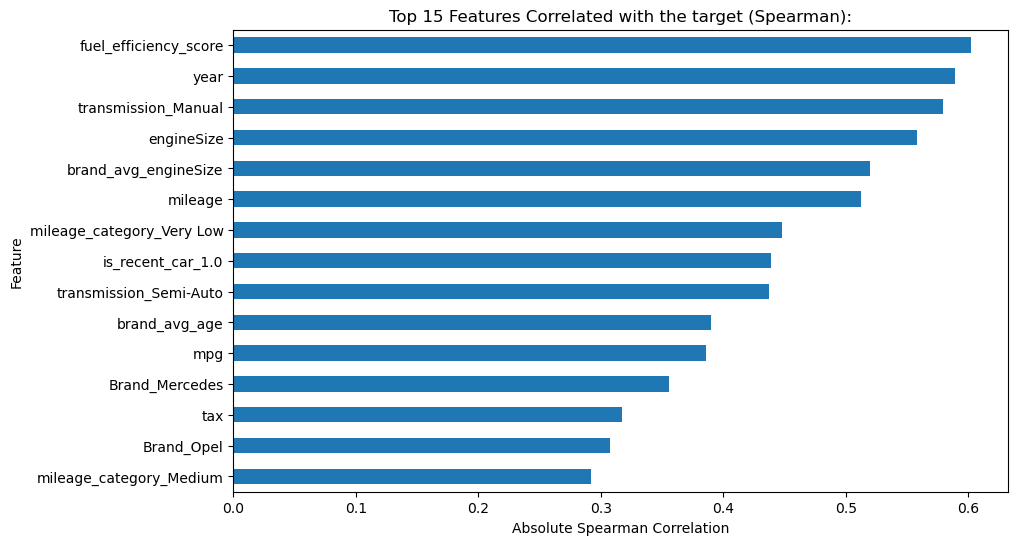

In [15]:
# Compute Spearman correlation for all features with the target
spearman_corr = X_train.apply(lambda feat: spearmanr(feat, y_train)[0])

# Absolute values and sort descending
spearman_corr = spearman_corr.abs().sort_values(ascending=False)

# Display top 15 features numerically
print("\nTop 15 Features Correlated with the target (Spearman):")
print(spearman_corr.head(15))

# Plot top 15 features
plt.figure(figsize=(10, 6))
spearman_corr.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 Features Correlated with the target (Spearman):")
plt.xlabel("Absolute Spearman Correlation")
plt.ylabel("Feature")
plt.show()

The results show that some technical and age-related features, such as fuel_efficiency_score, year, transmission_Manual and engineSize, have the strongest relationships with the target, indicating they are the most relevant predictors. In contrast, some brand and model features show weaker correlations, suggesting lower predictive importance.

We will compare these results with ANOVA and Elastic Net methods to then make a decision on which features to remove.

In [16]:
# Define threshold for feature selection
threshold = 0.01  # Example value, adjust as needed

# Select features with Spearman correlation above the threshold
selected_features_spearman = spearman_corr[spearman_corr > threshold].index.tolist()     

In [17]:
# Count the number of features selected and eliminated
num_selected = len(selected_features_spearman)           
num_total = X_train.shape[1]                   
num_eliminated = num_total - num_selected            

# Print summary
print(f"Total features: {num_total}")
print(f"Features selected by Spearman method: {num_selected}")
print(f"Features eliminated: {num_eliminated}")

Total features: 129
Features selected by Spearman method: 117
Features eliminated: 12


<a class="anchor" id="5_2">

## **5.2 Wrapped Methods**

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_2_1">

### **5.2.1 RFE**

[Back to TOP](#TOP)
</a>

In [18]:
# Train Lasso regression model
rfe_model = LinearRegression()
rfe = RFE(estimator = rfe_model, n_features_to_select = 20, step=5)

X_rfe = rfe.fit(X = X_train, y = y_train)

selected_features_rfe = X_train.columns[rfe.support_].tolist()

<a class="anchor" id="5_3">

## **5.3 Embedded Methods**

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_3_1">

### **5.3.1 Lasso**

[Back to TOP](#TOP)
</a>

We predicted that Lasso Regression (L1 Regularization) would overperform over Ridge (L2) because of its unique capability for automatic feature selection, but decided to test it anyway using ElasticNetCV.

In [19]:
# Train Lasso regression model
lasso_reg = Lasso()
lasso_reg.fit(X_train, y_train)

# Store coefficients in a Series
coef_lasso = pd.Series(lasso_reg.coef_, index = X_train.columns)

# Display all coefficients
coef_lasso.head(20)

year                     2065.435000
mileage                 -1984.676170
tax                       -20.563532
mpg                     -4078.017553
engineSize               4843.800407
previousOwners             21.631932
fuel_efficiency_score    4635.924095
tax_to_engine_ratio     -1240.671079
brand_median_mileage      943.289369
brand_avg_engineSize     2184.992371
model_median_tax          518.023273
fueltype_avg_mpg          706.038692
brand_avg_age            -346.168249
Brand_BMW               -4080.348138
Brand_Ford               -675.142594
Brand_Hyundai           -4383.087807
Brand_Mercedes              0.000000
Brand_Opel              -3427.673777
Brand_Skoda              -116.014147
Brand_Toyota             -916.321717
dtype: float64

Our predictions were confirmed (L1 Ratio = 1) and we will use Lasso as our primary Embedded Method.

While Ridge only shrinks coefficients close to zero (retaining all features), the Lasso penalty forces the coefficients of irrelevant features to be exactly zero, allowing it to perform true feature elimination. This is ideal for our high-dimensional, post-encoded dataset, as it provides an efficient and rigorous method for reducing the 130 remaining features to a cleaner subset for model training.

Our cross‑validation chose alpha ≈ 5.99 as the value that best balances bias and variance for this problem. Given the scale of our features and target, a relatively strong L1 regularization is beneficial. Weaker penalties (smaller alpha) would overfit, and stronger ones (larger alpha) would throw away too much signal.

When comparing these coefficients with the results gotten from the Spearman and ANOVA analysis, we see a few **contradictions**. For example, we previously found that the features "tax" and "Brand_Mercedes" were among the features that better helped explain the model, but Lasso gave them a coefficient = 0, effectively removing their contribution.

This might be explained because Spearman and ANOVA look at each feature in isolation and ask how strongly it is related to the target. Lasso, on the other hand, fits a model with all features together and asks whether each feature still improves prediction once the others are already in the model. 

If **“tax” or “Brand_Mercedes” are strongly correlated with other variables** (for example, other price‑related or brand‑related features), or if their extra contribution is small, Lasso can set their coefficients to zero even though they are individually well correlated with the target. In practice, that means those features carry signal, but **most of that signal is already captured by other predictors**, so their unique added value is small or redundant.

In [20]:
# Selected features
selected_features_lasso = coef_lasso[coef_lasso != 0].index.tolist()

print(f"Total features: {num_total}")
print("Number of features selected by Lasso:", sum(coef_lasso != 0))
print(f"Features eliminated: {len(coef_lasso) - sum(coef_lasso != 0)}")
print("Selected features:", selected_features_lasso)

Total features: 129
Number of features selected by Lasso: 114
Features eliminated: 15
Selected features: ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'fuel_efficiency_score', 'tax_to_engine_ratio', 'brand_median_mileage', 'brand_avg_engineSize', 'model_median_tax', 'fueltype_avg_mpg', 'brand_avg_age', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Opel', 'Brand_Skoda', 'Brand_Toyota', 'Brand_VW', 'model_ 2 Series', 'model_ 3 Series', 'model_ 4 Series', 'model_ 5 Series', 'model_ A Class', 'model_ A1', 'model_ A3', 'model_ A4', 'model_ A5', 'model_ A6', 'model_ A7', 'model_ Adam', 'model_ Amarok', 'model_ Arteon', 'model_ Astra', 'model_ Auris', 'model_ Avensis', 'model_ Aygo', 'model_ B Class', 'model_ B-MAX', 'model_ C-HR', 'model_ Citigo', 'model_ Combo Life', 'model_ Corsa', 'model_ Crossland X', 'model_ E Class', 'model_ EcoSport', 'model_ Edge', 'model_ Fabia', 'model_ Fiesta', 'model_ Focus', 'model_ GLC Class', 'model_ Galaxy', 'model_ Golf', 'model_ Gol

<a class="anchor" id="5_4">

## **5.4 Comparison between Models**

[Back to TOP](#TOP)
</a>

As we mentioned previously, we will construct a table that allows us to compare the decisions of the different selection methods we used and identify consistently important features for our regression model.

In [21]:
# Create comparison table for feature selection methods
comparison_df = pd.DataFrame({'Feature': X_train.columns})
comparison_df['Lasso'] = comparison_df['Feature'].isin(selected_features_lasso).astype(int)
comparison_df['RFE'] = comparison_df['Feature'].isin(selected_features_rfe).astype(int)
comparison_df['Spearman'] = comparison_df['Feature'].isin(selected_features_spearman).astype(int)

# Add 'Sum' column to count how many methods selected each feature
comparison_df['Sum'] = comparison_df[['Lasso', 'RFE', 'Spearman']].sum(axis=1)
# Show top 20 rows
print(comparison_df.head(20))
print('------------------------------------------------------------------------------------------------------')
# Show the shape of the dataframe so we can know how many features we have
print(comparison_df.shape)


                  Feature  Lasso  RFE  Spearman  Sum
0                    year      1    1         1    3
1                 mileage      1    0         1    2
2                     tax      1    0         1    2
3                     mpg      1    0         1    2
4              engineSize      1    1         1    3
5          previousOwners      1    0         0    1
6   fuel_efficiency_score      1    0         1    2
7     tax_to_engine_ratio      1    0         1    2
8    brand_median_mileage      1    0         1    2
9    brand_avg_engineSize      1    0         1    2
10       model_median_tax      1    0         1    2
11       fueltype_avg_mpg      1    0         1    2
12          brand_avg_age      1    0         1    2
13              Brand_BMW      1    0         1    2
14             Brand_Ford      1    0         1    2
15          Brand_Hyundai      1    1         1    3
16         Brand_Mercedes      0    0         1    1
17             Brand_Opel      1    1         

The resulting table shows, for each feature, whether it was selected (1) or eliminated (0) by each feature selection method: F-Regression, Elastic Net, and Spearman correlation.

A higher Sum value means more agreement between methods, suggesting that the feature is likely more important for predicting the target. Features with Sum = 0 were not selected by any method, indicating they are likely irrelevant.

Also based on this results, we can see a total of 130 features, but to be more conservative **we will keep only the features that were selected by all three methods (Sum= 3)**. This ensures that we retain only the most consistently important features.

In [22]:
# Select features agreed upon by all three methods
final_features = comparison_df[comparison_df['Sum'] >= 3]['Feature'].tolist()

# Reduce datasets to only these features
X_train_final = X_train[final_features]
X_val_final = X_val[final_features]
test_final = test[final_features]

# Print summary
print(f"Total features: {X_train.shape[1]}")
print(f"Features selected by all three methods: {len(final_features)}")
print(f"The shape of the dataframe is: {X_train_final.shape}")


Total features: 129
Features selected by all three methods: 20
The shape of the dataframe is: (60778, 20)


In [23]:
X_train_final.shape

(60778, 20)

In [24]:
X_train_final.columns

Index(['year', 'engineSize', 'Brand_Hyundai', 'Brand_Opel', 'model_ Fabia',
       'model_ GLC Class', 'model_ Ka+', 'model_ M4', 'model_ Q7',
       'model_ RS6', 'model_ SL CLASS', 'model_ Santa Fe', 'model_ Up',
       'model_ V Class', 'model_ X3', 'model_ X4', 'model_ X5', 'model_ Yaris',
       'fuelType_Hybrid', 'mileage_category_Very Low'],
      dtype='object')

<a class="anchor" id="6">

# **6 Save the Data**

[Back to TOP](#TOP)
</a>

This section saves the processed dataset containing only the selected features, ensuring it is ready to be used in the model assessment notebook.

In [25]:
# Go one level up from the notebooks folder to reach the repo root
selected_dir = "../data_feature_selected"
os.makedirs(selected_dir, exist_ok=True)

# Save processed datasets as CSV files
X_train_final.to_csv(f"{selected_dir}/X_train_final.csv", index=True)
X_val_final.to_csv(f"{selected_dir}/X_val_final.csv", index=True)
test_final.to_csv(f"{selected_dir}/test_final.csv", index=True)

y_train.to_csv(f"{selected_dir}/y_train.csv", index=True)
y_val.to_csv(f"{selected_dir}/y_val.csv", index=True)

<a class="anchor" id="7">

# **7 End of the Notebook**

[Back to TOP](#TOP)
</a>

The feature selection process refined the dataset and enhancing the overall performance of the predictive model. Several complementary techniques were applied to identify the most relevant features, reduce redundancy, and remove irrelevant features. This systematic approach helped ensure that the final set of features captured the most meaningful relationships with the target feature, improving both model efficiency and interpretability. Additionally, the dataset’s shape was continuously monitored after each step to confirm that all transformations were correctly applied and that the data remained consistent throughout the process.